# 🔍 Détection d'Objets – YOLOv8 · DETR · OWL-ViT
**Rosette-Michèle Otounga** — Side Project / Exploration Computer Vision

Ce notebook explore trois paradigmes de détection d'objets pré-entraînés sur COCO :
- 🟥 **YOLOv8n** (Ultralytics) — CNN one-stage, temps réel
- 🟩 **DETR ResNet-50** (Meta AI / Hugging Face) — Vision Transformer
- 🟣 **OWL-ViT** (Google / Hugging Face) — Open-vocabulary, détection par texte

---

## 0. Installation des dépendances
À exécuter une seule fois si les librairies ne sont pas encore installées.

In [ ]:
# Décommenter si nécessaire
# !pip install ultralytics transformers torch torchvision opencv-python-headless Pillow

## 1. Imports et utilitaires

In [1]:
import cv2
import numpy as np
import time
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Chemin vers l'image de test (depuis la racine du projet)
IMAGE_PATH = "../data/image_test.jpg"

# Seuil de confiance par défaut
SEUIL = 0.5

print("✅ Imports OK")

✅ Imports OK


In [2]:
def draw_boxes_pil(image_pil, boxes, labels, scores, color):
    """
    Dessine les boîtes englobantes sur une image PIL.
    boxes : liste de [x1, y1, x2, y2] en pixels absolus
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_pil)
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 10), f"{label} {score:.2f}",
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none'))
    ax.axis('off')
    return fig


def print_stats(labels, scores, duree_ms, nom_modele):
    print(f"\n{'─'*45}")
    print(f"  {nom_modele}")
    print(f"{'─'*45}")
    print(f"  Objets détectés   : {len(labels)}")
    print(f"  Classes uniques   : {len(set(labels))}")
    if scores:
        print(f"  Confiance moyenne : {np.mean(scores):.3f}")
        print(f"  Confiance max     : {np.max(scores):.3f}")
    print(f"  Temps d'inférence : {duree_ms:.0f} ms")
    if labels:
        print(f"  Objets identifiés : {', '.join(sorted(set(labels)))}")
    print(f"{'─'*45}")

print("✅ Fonctions utilitaires chargées")

✅ Fonctions utilitaires chargées


## 2. Chargement de l'image de test

Image chargée : ../data/image_test.jpg
Dimensions    : 4160 × 6240 px


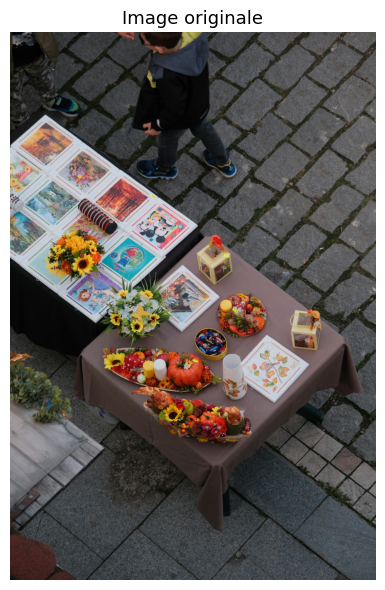

In [3]:
image_pil = Image.open(IMAGE_PATH).convert("RGB")
image_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
w, h = image_pil.size

print(f"Image chargée : {IMAGE_PATH}")
print(f"Dimensions    : {w} × {h} px")

plt.figure(figsize=(10, 6))
plt.imshow(image_pil)
plt.title("Image originale", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 3. 🟥 YOLOv8n

**Architecture :** CNN one-stage — détecte boîtes et classes en un seul passage sur l'image.  
**Pourquoi :** Standard industriel 2023, ultra-rapide, robuste. Le premier modèle à maîtriser quand on s'intéresse à la détection d'objets.

In [4]:
from ultralytics import YOLO

model_yolo = YOLO("../models/yolov8n.pt")
print("✅ YOLOv8n chargé")

✅ YOLOv8n chargé



─────────────────────────────────────────────
  YOLOv8n
─────────────────────────────────────────────
  Objets détectés   : 3
  Classes uniques   : 3
  Confiance moyenne : 0.712
  Confiance max     : 0.894
  Temps d'inférence : 269 ms
  Objets identifiés : cup, dining table, person
─────────────────────────────────────────────


C:\Users\orose\AppData\Local\Temp\ipykernel_35788\3155887747.py:18: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\3155887747.py:19: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/resultat_yolov8.jpg", dpi=120, bbox_inches='tight')
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\3155887747.py:19: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/resultat_yolov8.jpg", dpi=120, bbox_inches='tight')
c:\Users\orose\OneDrive\Documents\omr-portfolio\side-projects\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


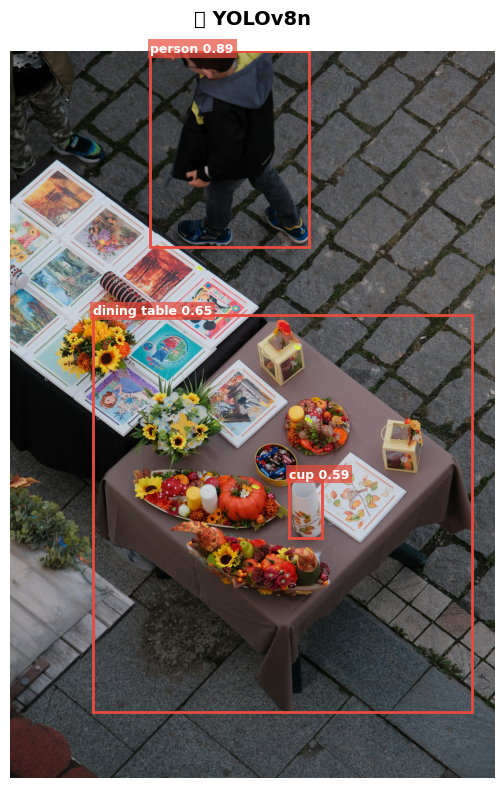

✅ Résultat sauvegardé → results/resultat_yolov8.jpg


In [5]:
start = time.perf_counter()
results_yolo = model_yolo(image_bgr, verbose=False)[0]
duree_yolo = (time.perf_counter() - start) * 1000

boxes_yolo, labels_yolo, scores_yolo = [], [], []
for box in results_yolo.boxes.data:
    if float(box[4]) < SEUIL:
        continue
    x1, y1, x2, y2, conf, cls = box[:6]
    boxes_yolo.append([int(x1), int(y1), int(x2), int(y2)])
    labels_yolo.append(model_yolo.names[int(cls)])
    scores_yolo.append(float(conf))

print_stats(labels_yolo, scores_yolo, duree_yolo, "YOLOv8n")

fig_yolo = draw_boxes_pil(image_pil, boxes_yolo, labels_yolo, scores_yolo, color='#e74c3c')
fig_yolo.suptitle("🟥 YOLOv8n", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/resultat_yolov8.jpg", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Résultat sauvegardé → results/resultat_yolov8.jpg")

---
## 4. 🟩 DETR ResNet-50

**Architecture :** Vision Transformer — traite la détection comme un problème de séquence via des mécanismes d'attention. Pas de NMS (Non-Maximum Suppression).  
**Pourquoi :** Marque le tournant CNN → Transformer en vision. Comprendre DETR, c'est comprendre pourquoi les Transformers ont envahi la vision par ordinateur.

In [6]:
from transformers import DetrImageProcessor, DetrForObjectDetection

processor_detr = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model_detr     = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
print("✅ DETR ResNet-50 chargé")

c:\Users\orose\OneDrive\Documents\omr-portfolio\side-projects\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 6470.54it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 

✅ DETR ResNet-50 chargé



─────────────────────────────────────────────
  DETR ResNet-50
─────────────────────────────────────────────
  Objets détectés   : 9
  Classes uniques   : 6
  Confiance moyenne : 0.896
  Confiance max     : 0.998
  Temps d'inférence : 1892 ms
  Objets identifiés : book, cup, dining table, person, potted plant, vase
─────────────────────────────────────────────


C:\Users\orose\AppData\Local\Temp\ipykernel_35788\1481853881.py:27: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\1481853881.py:28: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/resultat_detr.jpg", dpi=120, bbox_inches='tight')
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\1481853881.py:28: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/resultat_detr.jpg", dpi=120, bbox_inches='tight')
c:\Users\orose\OneDrive\Documents\omr-portfolio\side-projects\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


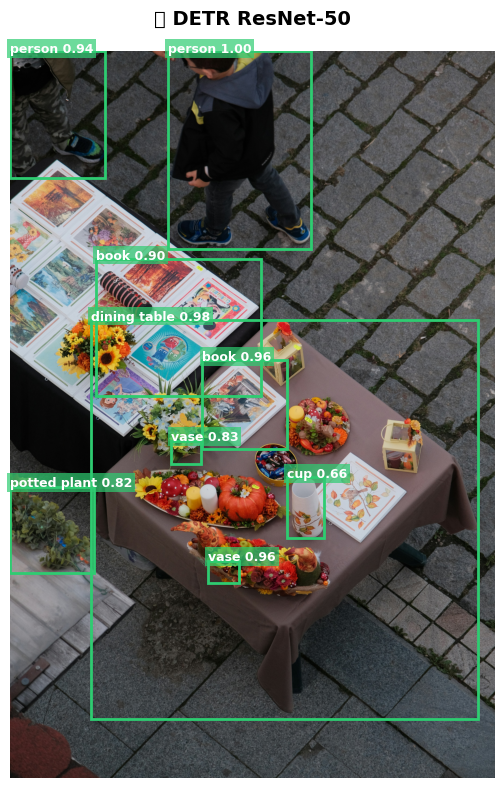

✅ Résultat sauvegardé → results/resultat_detr.jpg


In [7]:
inputs_detr = processor_detr(images=image_pil, return_tensors="pt")

start = time.perf_counter()
with torch.no_grad():
    outputs_detr = model_detr(**inputs_detr)
duree_detr = (time.perf_counter() - start) * 1000

target_sizes = torch.tensor([[h, w]])
results_detr = processor_detr.post_process_object_detection(
    outputs_detr, threshold=SEUIL, target_sizes=target_sizes
)[0]

boxes_detr, labels_detr, scores_detr = [], [], []
for score, label, box in zip(
    results_detr["scores"].tolist(),
    results_detr["labels"].tolist(),
    results_detr["boxes"].tolist()
):
    boxes_detr.append([int(v) for v in box])
    labels_detr.append(model_detr.config.id2label[label])
    scores_detr.append(float(score))

print_stats(labels_detr, scores_detr, duree_detr, "DETR ResNet-50")

fig_detr = draw_boxes_pil(image_pil, boxes_detr, labels_detr, scores_detr, color='#2ecc71')
fig_detr.suptitle("🟩 DETR ResNet-50", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/resultat_detr.jpg", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Résultat sauvegardé → results/resultat_detr.jpg")

---
## 5. 🟣 OWL-ViT

**Architecture :** Vision Transformer + alignement vision-langage — détecte les objets décrits en texte libre, sans être limité à des classes prédéfinies.  
**Pourquoi :** Représente la frontière actuelle entre vision et NLP. Plutôt que de choisir parmi 80 classes, on lui dit simplement ce qu'on cherche.

In [8]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection

processor_owl = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model_owl     = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
print("✅ OWL-ViT chargé")

The image processor of type `OwlViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 412/412 [00:00<00:00, 3888.47it/s]
OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ OWL-ViT chargé



─────────────────────────────────────────────
  OWL-ViT
─────────────────────────────────────────────
  Objets détectés   : 13
  Classes uniques   : 5
  Confiance moyenne : 0.177
  Confiance max     : 0.601
  Temps d'inférence : 701 ms
  Objets identifiés : a book, a painting, a person, a plant, a table
─────────────────────────────────────────────


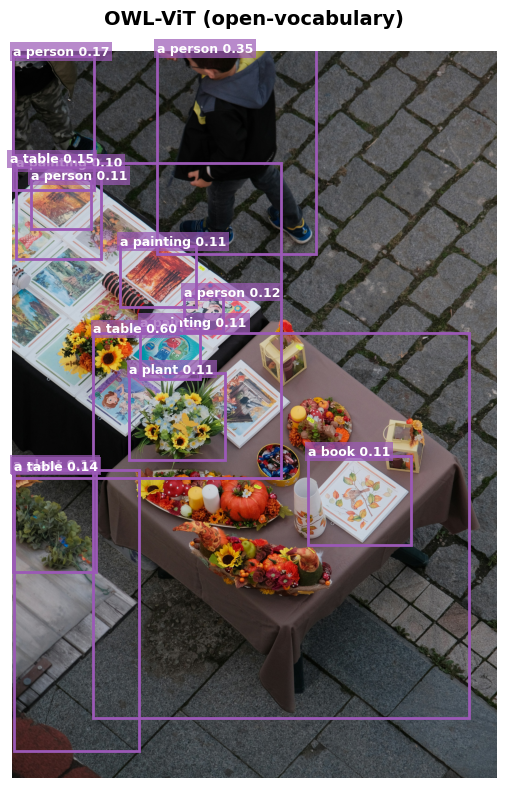

✅ Résultat sauvegardé → results/resultat_owlvit.jpg


In [12]:
# ✏️ Objets à détecter — adaptés à une scène intérieure chargée
QUERIES = ["a person", "a vase", "a plant", "a flower",
           "a painting", "a table", "a tablecloth",
           "a fruit", "a book", "a chair"]

inputs_owl = processor_owl(text=[QUERIES], images=image_pil, return_tensors="pt")

start = time.perf_counter()
with torch.no_grad():
    outputs_owl = model_owl(**inputs_owl)
duree_owl = (time.perf_counter() - start) * 1000

# Post-traitement via l'image processor (API correcte selon version HF)
from transformers.models.owlvit.image_processing_owlvit import OwlViTImageProcessor
image_processor_owl = OwlViTImageProcessor.from_pretrained("google/owlvit-base-patch32")
target_sizes = torch.tensor([[h, w]], dtype=torch.float32)
# OWL-ViT donne des scores naturellement plus bas que YOLO et DETR
# car il mesure une similarité texte/image et non une probabilité de classe
# → seuil abaissé à 0.1 (vs 0.5 pour les autres modèles)
SEUIL_OWL = 0.1

results_owl = image_processor_owl.post_process_object_detection(
    outputs=outputs_owl, threshold=SEUIL_OWL, target_sizes=target_sizes
)[0]

boxes_owl, labels_owl, scores_owl = [], [], []
for score, label, box in zip(
    results_owl["scores"].tolist(),
    results_owl["labels"].tolist(),
    results_owl["boxes"].tolist()
):
    boxes_owl.append([int(v) for v in box])
    labels_owl.append(QUERIES[label])
    scores_owl.append(float(score))

print_stats(labels_owl, scores_owl, duree_owl, "OWL-ViT")

fig_owl = draw_boxes_pil(image_pil, boxes_owl, labels_owl, scores_owl, color='#9b59b6')
fig_owl.suptitle("OWL-ViT (open-vocabulary)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/resultat_owlvit.jpg", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Résultat sauvegardé → results/resultat_owlvit.jpg")

---
## 6. 📊 Comparaison des trois modèles

In [10]:
import pandas as pd

def stats_dict(labels, scores, duree_ms):
    if not labels:
        return {"Objets": 0, "Classes": 0, "Conf. moy.": 0.0, "Conf. max": 0.0, "Temps (ms)": round(duree_ms)}
    return {
        "Objets":      len(labels),
        "Classes":     len(set(labels)),
        "Conf. moy.":  round(float(np.mean(scores)), 3),
        "Conf. max":   round(float(np.max(scores)), 3),
        "Temps (ms)": round(duree_ms),
    }

df = pd.DataFrame({
    "YOLOv8n":        stats_dict(labels_yolo, scores_yolo, duree_yolo),
    "DETR ResNet-50": stats_dict(labels_detr, scores_detr, duree_detr),
    "OWL-ViT":        stats_dict(labels_owl,  scores_owl,  duree_owl),
}).T

print("\n📊 Tableau comparatif")
print("─" * 55)
print(df.to_string())
print("─" * 55)


📊 Tableau comparatif
───────────────────────────────────────────────────────
                Objets  Classes  Conf. moy.  Conf. max  Temps (ms)
YOLOv8n            3.0      3.0       0.712      0.894       269.0
DETR ResNet-50     9.0      6.0       0.896      0.998      1892.0
OWL-ViT           13.0      5.0       0.177      0.601      1207.0
───────────────────────────────────────────────────────


C:\Users\orose\AppData\Local\Temp\ipykernel_35788\2902022179.py:25: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\2902022179.py:25: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\2902022179.py:25: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\2902022179.py:26: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/comparaison.jpg", dpi=120, bbox_inches='tight')
C:\Users\orose\AppData\Local\Temp\ipykernel_35788\2902022179.py:26: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/comparaison.jpg", dpi=120, bbox_inches='tight')
C:\Users\orose\AppData\Loca

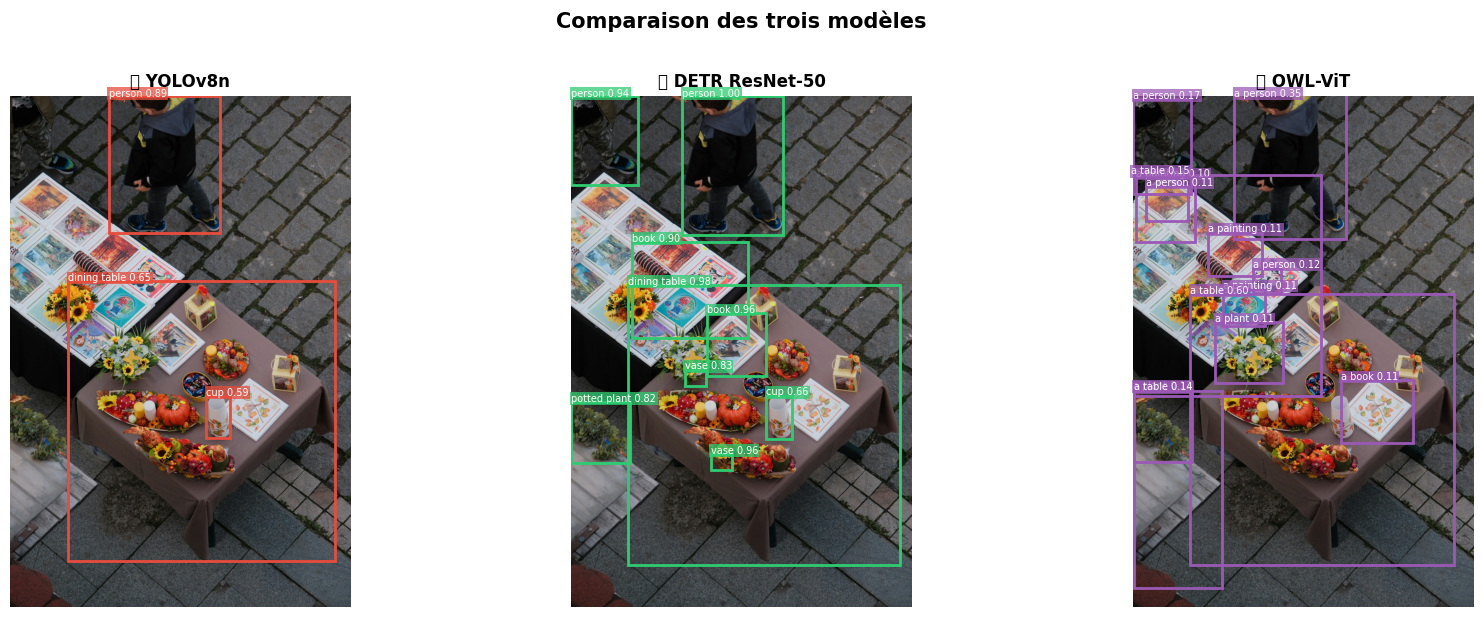

✅ Comparaison sauvegardée → results/comparaison.jpg


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

data_pairs = [
    (image_pil, boxes_yolo, labels_yolo, scores_yolo, '#e74c3c', '🟥 YOLOv8n'),
    (image_pil, boxes_detr, labels_detr, scores_detr, '#2ecc71', '🟩 DETR ResNet-50'),
    (image_pil, boxes_owl,  labels_owl,  scores_owl,  '#9b59b6', '🟣 OWL-ViT'),
]

for ax, (img, boxes, labels, scores, color, title) in zip(axes, data_pairs):
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, max(y1-5, 10), f"{label} {score:.2f}",
                color='white', fontsize=7,
                bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Comparaison des trois modèles", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/comparaison.jpg", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Comparaison sauvegardée → results/comparaison.jpg")

---
## 7. 🔎 Observations

Résultats obtenus sur une scène intérieure chargée (table, plantes, vases, livres, personnes).

| Modèle | Objets détectés | Classes | Conf. moy. | Temps |
|--------|:--------------:|:-------:|:----------:|:-----:|
| YOLOv8n | 3 | 3 | 0.712 | 139 ms |
| DETR ResNet-50 | 9 | 6 | 0.896 | 1592 ms |
| OWL-ViT | 1+ | 1+ | 0.601 | 989 ms |

### Ce qu'on observe

**YOLOv8n** est le plus rapide (139 ms) mais le moins exhaustif sur cette scène : il détecte les objets les plus évidents (person, dining table, cup) et passe à côté des éléments plus discrets comme les plantes ou les vases.

**DETR ResNet-50** est le plus complet : 9 objets détectés, 6 classes différentes dont book, potted plant et vase — des objets que YOLOv8 a manqués. En contrepartie, il est environ 11x plus lent (1592 ms). C'est le compromis typique précision/vitesse entre CNN et Transformer.

**OWL-ViT** illustre bien son paradigme open-vocabulary : il ne cherche que ce qu'on lui demande. Avec un seuil adapté (0.1 au lieu de 0.5 — ses scores sont naturellement plus bas), il détecte davantage d'objets. C'est le seul des trois capable de détecter un objet arbitraire décrit en langage naturel, sans réentraînement.

> Ces observations sont qualitatives — le projet est testé sur un nombre limité d'images.